In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def bisection(f, L, R, eps, maxiter):
    if L > R: 
        print("Range Invalid!")
        return None
        
    if abs(f(L)) <= eps:
        print(f"Root Found on {iteration} iterations!")
        return 0, L
            
    if abs(f(R)) <= eps:
        print(f"Root Found on {iteration} iterations!")
        return 0, R   
        
    
    iteration = 1
    while iteration <= maxiter:
        center = (L + R)/2        
        f_left = f(L)
        f_right = f(R)
        f_center = f(center)
        if f_left*f_center < 0:
            R = center
        else:
            L = center
            
        if abs(f_center) <= eps:
            print(f"Root Found on {iteration} iterations!")
            return iteration, center

        iteration += 1
        
    if iteration == maxiter:
        print("Root Not Found!")
        return None

In [3]:
def secant(f, left, right, eps, maxiter):
    if left > right:
        print("Range Invalid!")
        return None
    
    # check if the interval boundaries are the roots
    if abs(f(left)) <= eps:
        print(f"Root Found on {iteration} iterations!")
        return 0, left
            
    if abs(f(right)) <= eps:
        print(f"Root Found on {iteration} iterations!")
        return 0, right   
    
    iteration = 1
    while iteration <= maxiter:
        slope = (f(right) - f(left))/(right - left)
        temp = right - f(right)/(slope + 1e-10)
        if abs(f(right)) <= eps:
            print(f"Root Found on {iteration} iterations!")
            return iteration, right        
        left, right = right, temp
        iteration += 1
    if iteration == maxiter:
        print("Root Not Found!")
        return None

In [4]:
def NewtonRapson(f, df, start, eps, maxiter):    
    iteration = 1
    while iteration <= maxiter:
        temp = start - f(start)/(df(start) + 1e-10)         
        if abs(f(temp)) <= eps:
            print(f"Root Found on {iteration} iterations!")
            return iteration, temp    

        start = temp
        iteration += 1
    if iteration == maxiter:
        print("Root Not Found!")
        return None

In [41]:
def bisection_discrete(f, x, left_id, right_id, eps, maxiter):
    if left_id > right_id:
        return None
    
    f_l = f[left_id]
    f_r = f[right_id]
    
    if abs(f_l) <= eps:
        return 0, left_id, x[left_id]
    if abs(f_r) <= eps:
        return 0, right_id, x[right_id]
    
    # Ensure a sign change exists
    if f_l * f_r > 0:
        return None

    l, r = left_id, right_id
    
    for iteration in range(1, maxiter + 1):
        if r - l <= 1:
            print("Tolerance Not Satisfied! Interpolating Root")
            root_interp = x[l] - f_l * (x[r] - x[l]) / (f_r - f_l)
            return iteration, None, root_interp
        
        c = (l + r) // 2
        f_c = f[c]
        
        if abs(f_c) <= eps:
            return iteration, c, x[c]
        
        if f_l * f_c < 0:
            r = c
            f_r = f_c
        else:
            l = c
            f_l = f_c
            

            
    return None

In [46]:
def secant_discrete(f, x, left_id, right_id, eps, maxiter):
    if left_id >= len(f) or right_id >= len(f):
        return None
    
    f_l = f[left_id]
    f_r = f[right_id]
    
    if abs(f_l) <= eps:
        return 0, left_id, x[left_id]
    if abs(f_r) <= eps:
        return 0, right_id, x[right_id]
    
    l = left_id
    r = right_id
    
    for iteration in range(1, maxiter + 1):
        denominator = x[r] - x[l]
        if abs(denominator) < 1e-12:
            break
            
        slope = (f[r] - f[l]) / denominator
        x_next = x[r] - f[r] / (slope + 1e-10)
        next_id = np.abs(x - x_next).argmin()
        if abs(f[next_id]) <= eps:
            return iteration, next_id, x[next_id]
        
        if next_id == r:
            print("Convergence stalled at discrete index.")
            return iteration, None, x_next
            
        l, r = r, next_id
        
    print("Root Not Found within maxiter!")
    return None

In [47]:
def f(x):
    return x

def df(x):
    return 1

xmin = -1
xmax = 1
maxiter = 100
eps = 1e-5

root1 = bisection(f, xmin, xmax, eps, maxiter)[1]
root2 = secant(f, xmin, xmax, eps, maxiter)[1]
root3 = NewtonRapson(f, df, xmin, eps, maxiter)[1]

print(f"{root1}\t{root2}\t{root3}")

Root Found on 1 iterations!
Root Found on 2 iterations!
Root Found on 1 iterations!
0.0	1.000000082740371e-10	-1.000000082740371e-10


Tolerance Not Satisfied! Interpolating Root
Convergence stalled at discrete index.
(12, None, np.float64(1.8932890629505825))


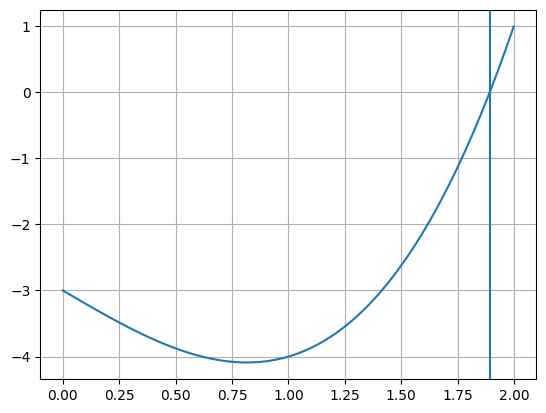

(5, None, np.float64(1.8932873821835352))


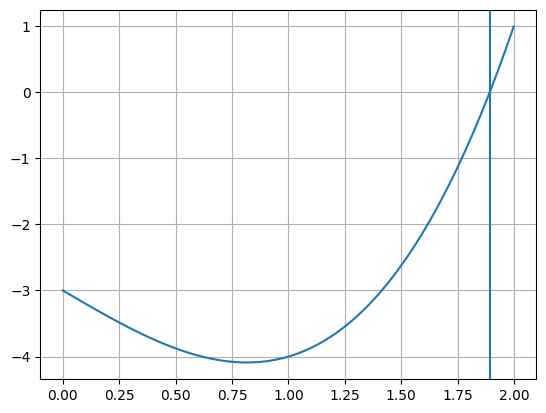

In [48]:
def f(x):
    return x*x*x - 2*x -3

def df(x):
    return 1

xmin = 0
xmax = 2
maxiter = 100
eps = 1e-3

x = np.arange(xmin, xmax, eps)
f_x = f(x)

root1 = bisection_discrete(f_x, x, 0, len(x) - 1, eps, maxiter)
root2 = secant_discrete(f_x, x, 0, len(x) - 1, eps, maxiter)

if root1 != None:
    print(f"{root1}")
    if root1[1] != None:
        print(f"f(x): {f_x[root1[1]]}")


    plt.plot(x, f_x)
    plt.axvline(root1[2])
    plt.grid()
    plt.show()


if root2 != None:
    print(f"{root2}")
    if root1[1] != None:
        print(f"f(x): {f_x[root2[1]]}")


    plt.plot(x, f_x)
    plt.axvline(root2[2])
    plt.grid()
    plt.show()